In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

sharks_df=pd.read_excel('EDA_Shark_Tank_India.xlsx')
sharks_df

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1,50.0,5.0,1000.00,75.0,16.00,...,1,0,1,0,1,0,0,3,25.0,5.333333
1,1,2,Booz scooters,Renting e-bike for mobility in private spaces,,40.0,15.0,266.67,40.0,50.00,...,1,0,0,0,1,0,0,2,20.0,25
2,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.0,10.0,250.00,25.0,30.00,...,0,1,0,0,1,0,0,2,12.5,
3,2,4,Tagz Foods,Healthy Potato Chips,1,70.0,1.0,7000.00,70.0,2.75,...,1,0,0,0,0,0,0,1,70.0,2.75
4,2,5,Head and Heart,Brain Development Course,0,50.0,5.0,1000.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,34,113,Green Protein,Plant-Based Protein,0,60.0,2.0,3000.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0
115,34,114,On2Cook,Fastest Cooking Device,0,100.0,1.0,10000.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0
116,35,115,Jain Shikanji,Lemonade,1,40.0,8.0,500.00,40.0,30.00,...,1,1,1,0,1,0,0,4,10.0,7.5
117,35,116,Woloo,Washroom Finder,0,50.0,4.0,1250.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0


In [2]:
#Performing data cleanup steps

#Removing duplicates
sharks_df=sharks_df.drop_duplicates(subset=['episode_number', 'pitch_number'],keep='first',)

# For missing values in deal, replace it with 1. 
#This is because deal was finally done and this can be confirmed by non zero values in total_sharks_invested, amount_per_shark or equity_per_shark
sharks_df.loc[sharks_df['deal']==' ', 'deal']=sharks_df['deal'].mask(sharks_df['deal']==' ',1)

#For missing values in equity_per_shark, replace with mean of non zero values
sharks_df.loc[sharks_df['equity_per_shark'] == ' ', 'equity_per_shark']=sharks_df['equity_per_shark'].mask(sharks_df['equity_per_shark']== ' ', np.nan)
m=sharks_df[(sharks_df['equity_per_shark'].notna()) & (sharks_df['equity_per_shark']>0)]['equity_per_shark'].mean()
sharks_df.loc[sharks_df['equity_per_shark'].isna(), 'equity_per_shark']=sharks_df['equity_per_shark'].mask(sharks_df['equity_per_shark'].isna(), m)

#There is one record with following details:
#episode_number	pitch_number	brand_name			idea
#7				19				Raising Superstars	Child Development App
#It has value of deal as 0 but deal was done. Therefore we will change value of deal from 0 to 1
sharks_df.loc[(sharks_df['deal']==0) & (sharks_df['equity_per_shark']>0), 'deal']=1


Project Questions:

In [3]:
# 1. How many deals were successfully made and what percentage of total pitches did they constitute?
deals_made=sharks_df[sharks_df['deal']==1].shape[0]
success_deal_precent=round((deals_made/sharks_df.shape[0])*100  ,2)
print('Total deals made:', deals_made,", Percentage:",success_deal_precent)
#Ans: Total deals made: 67. Percentage of made_deals with respect to total deals=57.26

Total deals made: 67 , Percentage: 57.26


In [5]:
# 2. What is the average and median deal_amount for pitches that received investment?
avg_deal_amount=round(sharks_df['deal_amount'].mean(),2)
median_deal_amount=sharks_df['deal_amount'].median()
print('avg deal amount:',avg_deal_amount,'median_deal_amount:',median_deal_amount)
#Ans: Avg deal: 67. Median deal=57.26

avg deal amount: 31.98 median_deal_amount: 25.0


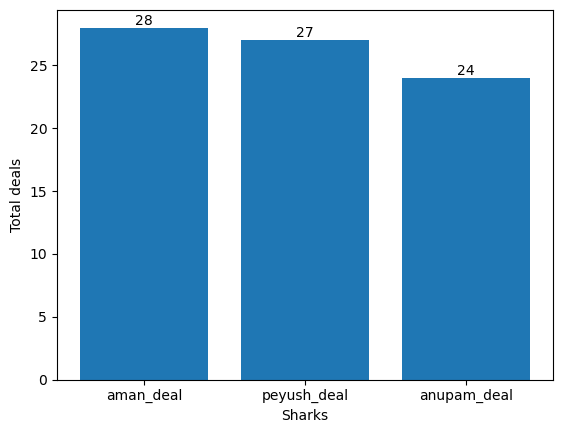

In [6]:
# 3. mWhich shark has made the highest number of investments? Provide a visualization of top 3 sharks.
import matplotlib.pyplot as plt
sharks_deals=sharks_df[["ashneer_deal","anupam_deal", "aman_deal","namita_deal","vineeta_deal",	"peyush_deal",	"ghazal_deal"]].sum()\
.sort_values(ascending=False).head(3)
for i, v in enumerate(sharks_deals.values):
    plt.text(i, v , str(v), ha='center', va='bottom')
plt.bar(sharks_deals.index, sharks_deals.values)
plt.xlabel('Sharks')
plt.ylabel('Total deals')
plt.show()

In [10]:
# 4.What is the total amount invested by all sharks combined in entire season.
total_amount_invested=round(sharks_df['deal_amount'].sum(),2)
print('total_amount_invested:',total_amount_invested)

total_amount_invested: 3742.0


In [11]:
# 5. How does the deal_equity distribution look? Are there any outliers?
Q1=sharks_df['deal_equity'].quantile(.25)
Q3=sharks_df['deal_equity'].quantile(.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers_df=sharks_df[(sharks_df['deal_equity']<lower_bound) | (sharks_df['deal_equity']>upper_bound)]
display(outliers_df)
#There are 5 outliers as shown below

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
1,1,2,Booz scooters,Renting e-bike for mobility in private spaces,1,40.0,15.0,266.67,40.0,50.0,...,1,0,0,0,1,0,0,2,20.0,25
43,15,43,Hammer Lifestyle,Smart Audio Products,1,30.0,3.0,1000.00,100.0,40.0,...,0,0,1,0,0,0,0,1,100.0,40
66,21,66,Sid07 Designs,Inventions,1,47.0,10.0,470.00,25.0,75.0,...,0,0,0,0,0,1,0,1,25.0,75
77,24,77,KG Agrotech,Agricultural Innovations,1,30.0,10.0,300.00,10.0,40.0,...,0,0,0,0,0,1,0,1,10.0,40
82,26,82,Isak Fragrances,Perfumes,1,50.0,8.0,625.00,50.0,50.0,...,0,0,0,0,0,1,0,1,50.0,50


In [12]:
#6 Find the correlation between deal_valuation and ask_valuation. What insight can be drawn from this?
cor=round(sharks_df['deal_valuation'].corr(sharks_df['ask_valuation']),2)
print(cor)
#Ans Correlation between deal_valuation and ask_valuation is .02, which is a weak positive correlation.


0.02


In [13]:
# 7. What is the average equity percentage given to the sharks per deal?
avg_equity_percentage=round((sharks_df['deal_equity'].sum()/sharks_df['equity_per_shark'].sum())*100, 2)
avg_equity_percentage
#Ans: 159.33

159.33

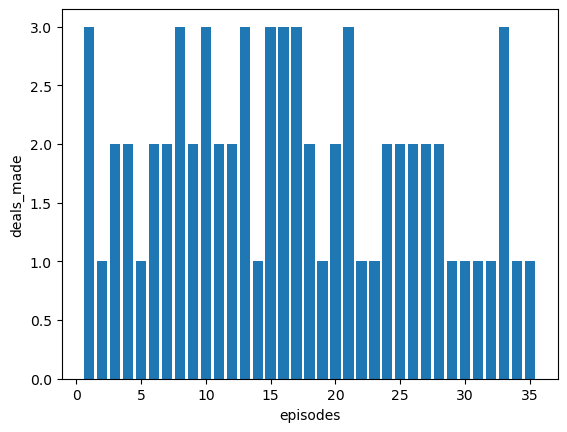

In [14]:
### 8. Identify which episode had the highest number of deals and visualize it.
deals_per_episode=sharks_df[sharks_df['deal']==1].groupby('episode_number')['deal'].count().sort_values(ascending=False)
plt.bar(deals_per_episode.index, deals_per_episode.values)
plt.xlabel('episodes')
plt.ylabel('deals_made')
plt.show()

In [15]:
# 9.How many pitches asked for more than ₹1 crore and how many of those received investments?
# I do not see any pitch greater than 1 Cr. Highest pitch amount I could see is 30000 for Gopal's 56, a Fiber Ice Cream. If pitch amount mentioned
# is in some different unit, then unit is missing and not mentioned. I assume it to be INR only.

In [16]:
# 10.What percentage of pitches involved more than one shark investing together?
sharks_df[sharks_df['total_sharks_invested']>1]

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1,50.00000,5.0,1000.00,75.00000,16.0,...,1,0,1,0,1,0,0,3,25.000000,5.333333
1,1,2,Booz scooters,Renting e-bike for mobility in private spaces,1,40.00000,15.0,266.67,40.00000,50.0,...,1,0,0,0,1,0,0,2,20.000000,25
2,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.00000,10.0,250.00,25.00000,30.0,...,0,1,0,0,1,0,0,2,12.500000,9.973125
9,4,10,Cosiq,Intelligent Skincare,1,50.00000,7.5,666.67,50.00000,25.0,...,0,1,0,0,1,0,0,2,25.000000,12.5
12,4,12,Bummer,Underwear,1,75.00000,4.0,1875.00,75.00000,7.5,...,0,0,1,1,0,0,0,2,37.500000,3.75
13,5,13,Revamp Moto,E-Bike,1,100.00000,1.0,10000.00,100.00000,1.5,...,0,1,1,0,0,0,0,2,50.000000,0.75
16,6,16,Skippi Pops,Ice-Pops,1,45.00000,5.0,900.00,100.00000,15.0,...,1,1,1,1,1,0,0,5,20.000000,3
19,7,19,Raising Superstars,Child Development App,1,100.00000,2.0,5000.00,100.00000,4.0,...,1,0,1,0,0,0,0,2,50.000000,2
22,8,22,Beyond Snack,Kerala Banana Chips,1,50.00000,2.5,2000.00,50.00000,2.5,...,1,0,1,0,0,0,0,2,25.000000,1.25
23,8,23,Vivalyf Innovations- Easy Life,Prickless Diabetes Testing Machine,1,56.00000,7.5,746.67,56.00000,33.3,...,0,1,0,0,0,1,0,2,28.000000,16.65


In [17]:
# 11. How does the investment behavior of Ashneer Grover compare with Peyush Bansal in terms of total amount invested?
peyush_deal_amount=sharks_df[(sharks_df['peyush_deal']==1) & (sharks_df['total_sharks_invested']==1)]['deal_amount'].sum()
ashneer_deal_amount=sharks_df[(sharks_df['ashneer_deal']==1) & (sharks_df['total_sharks_invested']==1)]['deal_amount'].sum()
print('peyush_deal_amount',peyush_deal_amount,'ashneer_deal_amount',ashneer_deal_amount)
#Peyush invested more than Ashneer.

peyush_deal_amount 330.0 ashneer_deal_amount 101.0


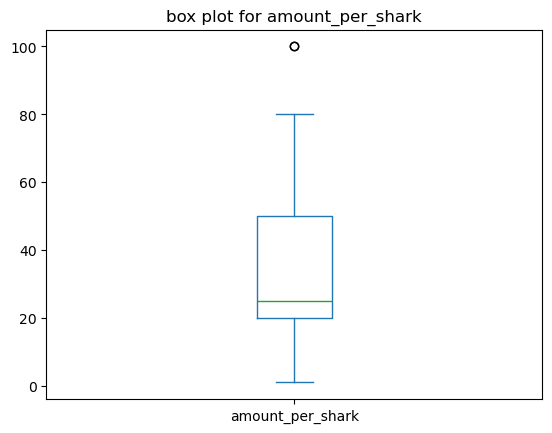

In [18]:
# 12. Create a box plot to analyze amount_per_shark. What insights can be gathered?
sharks_df[sharks_df['amount_per_shark']>=1]['amount_per_shark'].plot(kind='box', title='box plot for amount_per_shark')
plt.show()
# min value is 1, max is hundred. 100 is also an outlier. 
# 20 is first quantile, approx 23 is second quantile, and around 48 is third quantile

In [19]:
# 13. Are there any cases where the deal_amount exceeded the pitcher_ask_amount? If yes, list those cases.
sharks_df[sharks_df['deal_amount']>sharks_df['pitcher_ask_amount']]
#Ans There are 10 cases

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1,50.0,5.0,1000.0,75.0,16.0,...,1,0,1,0,1,0,0,3,25.000000,5.333333
16,6,16,Skippi Pops,Ice-Pops,1,45.0,5.0,900.0,100.0,15.0,...,1,1,1,1,1,0,0,5,20.000000,3
37,13,37,Annie,Braille Literary Device,1,30.0,5.0,600.0,105.0,3.0,...,0,1,0,1,0,1,0,3,35.000000,1
39,13,39,The Yarn Bazaar,Yarn-Trading App,1,50.0,2.0,2500.0,100.0,10.0,...,1,1,1,0,0,1,0,4,25.000000,2.5
43,15,43,Hammer Lifestyle,Smart Audio Products,1,30.0,3.0,1000.0,100.0,40.0,...,0,0,1,0,0,0,0,1,100.000000,40
59,19,59,WeSTOCK,Livestock health monitoring AI,1,50.0,5.0,1000.0,60.0,10.0,...,1,0,1,1,0,1,0,4,15.000000,2.5
64,20,64,IN A CAN,Can Cocktails,1,50.0,2.0,2500.0,100.0,10.0,...,1,1,1,1,0,1,0,5,20.000000,2
76,24,76,The Sass Bar,Gifts,1,40.0,8.0,500.0,50.0,35.0,...,0,1,0,0,0,0,1,2,25.000000,17.5
90,28,89,Humpy A2,Organic Milk Products,1,75.0,4.0,1875.0,100.0,15.0,...,0,0,0,0,1,1,1,3,33.333333,5
110,33,109,Tweek Labs,Sportswear,1,40.0,2.0,2000.0,60.0,10.0,...,1,1,0,0,0,1,0,3,20.000000,3.333333


In [20]:
# 14. Which shark has the highest return on investment (ROI) based on deal_amount vs. deal_equity?
tmp_df=sharks_df[sharks_df['amount_per_shark']>=1][["deal_amount","deal_equity","ashneer_deal","anupam_deal","aman_deal","namita_deal","vineeta_deal","peyush_deal","ghazal_deal"]]
tmp_df['roi']=tmp_df['deal_equity']/tmp_df['deal_amount']
ashneer_roi=tmp_df[tmp_df['ashneer_deal']>0]['roi'].mean()
print('avg ashneer_roi',ashneer_roi)

anupam_roi=tmp_df[tmp_df['anupam_deal']>0]['roi'].mean()
print('avg anupam_roi',anupam_roi)

aman_roi=tmp_df[tmp_df['aman_deal']>0]['roi'].mean()
print('avg aman_roi',aman_roi)

namita_roi=tmp_df[tmp_df['namita_deal']>0]['roi'].mean()
print('avg namita_roi',namita_roi)

vineeta_roi=tmp_df[tmp_df['vineeta_deal']>0]['roi'].mean()
print('avg vineeta_roi',vineeta_roi)

peyush_roi=tmp_df[tmp_df['peyush_deal']>0]['roi'].mean()
print('avg peyush_roi',peyush_roi)

ghazal_roi=tmp_df[tmp_df['ghazal_deal']>0]['roi'].mean()
print('avg ghazal_roi',ghazal_roi)
# Based on the avg return on investment, peyush got the highest return on investment with an average of .60 shares per unit amount of money invested.

avg ashneer_roi 0.3196485260770975
avg anupam_roi 0.3736634199134199
avg aman_roi 0.25150864197530864
avg namita_roi 0.25990293040293044
avg vineeta_roi 0.4876031746031746
avg peyush_roi 0.606341575091575
avg ghazal_roi 0.38166666666666665


In [21]:
# 15.Identify trends in equity distribution—are sharks investing in lower or higher equity stakes over time?
# If the query is about distribution of number of equities per shark, then it is a mixed distribution. I do not see any trend.

In [23]:
#16. What is the relationship between pitcher_ask_amount and deal_amount? Do pitchers who ask for less tend to secure more deals?
# mean when deal is made is 58
pitcher_amount_deals_made=sharks_df[sharks_df['amount_per_shark']>=1]['pitcher_ask_amount'].describe()
# mean when deal is not made is 648
pitcher_amount_deals_no_made=sharks_df[sharks_df['amount_per_shark']==0]['pitcher_ask_amount'].describe()
print(pitcher_amount_deals_made, pitcher_amount_deals_no_made)
# This means if pitcher pitch for less amount then it is more likely to secure deal.

count     63.000000
mean      58.380952
std       25.046685
min       25.000000
25%       40.000000
50%       50.000000
75%       75.000000
max      150.000000
Name: pitcher_ask_amount, dtype: float64 count       52.000000
mean       648.846154
std       4150.348038
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max      30000.000000
Name: pitcher_ask_amount, dtype: float64


In [24]:
# 17. Identify if there is a pattern in episode-wise deal closures—do certain episodes see more investments?
# Episodes order by max number of deals
display(sharks_df[sharks_df['amount_per_shark']>=1].groupby('episode_number')['deal_amount'].count().sort_values(ascending=False))
# Episodes order by total valuation of deals
display(sharks_df[sharks_df['amount_per_shark']>=1].groupby('episode_number')['deal_amount'].sum().sort_values(ascending=False))
# Episodes 17,13,16,21 have maximum number and amount of deals.

episode_number
1     3
21    3
33    3
8     3
10    3
17    3
16    3
13    3
15    2
25    2
24    2
28    2
20    2
26    2
12    2
11    2
9     2
6     2
4     2
3     2
27    1
31    1
30    1
29    1
34    1
32    1
18    1
23    1
22    1
19    1
2     1
14    1
7     1
5     1
35    1
Name: deal_amount, dtype: int64

episode_number
17    280.0
13    255.0
16    170.0
21    160.0
28    150.0
25    150.0
6     150.0
20    140.0
1     140.0
8     136.0
4     125.0
15    125.0
12    115.0
26    115.0
33    110.0
9     100.0
14    100.0
27    100.0
7     100.0
5     100.0
3      95.0
10     85.0
11     80.0
30     80.0
29     75.0
31     75.0
2      70.0
24     60.0
19     60.0
22     60.0
23     50.0
32     50.0
34     40.0
35     40.0
18      1.0
Name: deal_amount, dtype: float64

In [25]:
# 18.Analyze the impact of equity dilution on deal_valuation. Are lower equity asks leading to higher deal valuations?
tmp_df=sharks_df[sharks_df['deal_valuation']>0][["ask_equity","deal_valuation"]]
cor=tmp_df['deal_valuation'].corr(tmp_df['ask_equity'])
print(cor)
#There is medium negative correlation between deal_valuation and ask_equity. This means lower ask equity leads to higher deal valuations for scuccessful
#deals made.

-0.5008698905300211
